In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully")

All libraries loaded successfully


In [2]:
# Load all datasets
orders = pd.read_csv('olist_orders_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')

# Check shapes
print("Orders:", orders.shape)
print("Items:", items.shape)
print("Sellers:", sellers.shape)
print("Reviews:", reviews.shape)
print("Products:", products.shape)

Orders: (99441, 8)
Items: (112650, 7)
Sellers: (3095, 4)
Reviews: (99224, 7)
Products: (32951, 9)


In [3]:
# Master merge
df = orders.merge(items, on='order_id', how='left') \
           .merge(reviews[['order_id','review_score']], on='order_id', how='left') \
           .merge(sellers, on='seller_id', how='left') \
           .merge(products[['product_id','product_category_name']],
                  on='product_id', how='left')

print("Master dataframe shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nMissing values per column:")
print(df.isnull().sum())

Master dataframe shape: (114092, 19)

Column names:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'review_score', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'product_category_name']

Missing values per column:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 162
order_delivered_carrier_date     1980
order_delivered_customer_date    3253
order_estimated_delivery_date       0
order_item_id                     778
product_id                        778
seller_id                         778
shipping_limit_date               778
price                             778
freight_value                     778
review

In [4]:
# Convert datetime columns
date_cols = ['order_purchase_timestamp',
             'order_delivered_customer_date',
             'order_estimated_delivery_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

# Create delivery features
df['delivery_delay_days'] = (
    df['order_delivered_customer_date'] -
    df['order_estimated_delivery_date']
).dt.days

df['actual_delivery_days'] = (
    df['order_delivered_customer_date'] -
    df['order_purchase_timestamp']
).dt.days

# Target variable — review score <= 2 = dissatisfied customer
df['is_dissatisfied'] = (df['review_score'] <= 2).astype(int)

# Drop rows where delivery date or review score is missing
# These are essential columns — we cannot impute them meaningfully
df_clean = df.dropna(subset=['order_delivered_customer_date',
                              'review_score',
                              'delivery_delay_days'])

# Fill missing category with 'unknown'
df_clean['product_category_name'] = df_clean['product_category_name'].fillna('unknown')

# Final check
print("Clean dataframe shape:", df_clean.shape)
print(f"Rows dropped: {df.shape[0] - df_clean.shape[0]}")
print(f"\nDissatisfaction rate: {df_clean['is_dissatisfied'].mean():.2%}")
print(f"\nDelivery delay stats:")
print(df_clean['delivery_delay_days'].describe())

Clean dataframe shape: (110012, 22)
Rows dropped: 4080

Dissatisfaction rate: 14.80%

Delivery delay stats:
count    110012.000000
mean        -12.070738
std          10.092261
min        -147.000000
25%         -17.000000
50%         -13.000000
75%          -7.000000
max         188.000000
Name: delivery_delay_days, dtype: float64


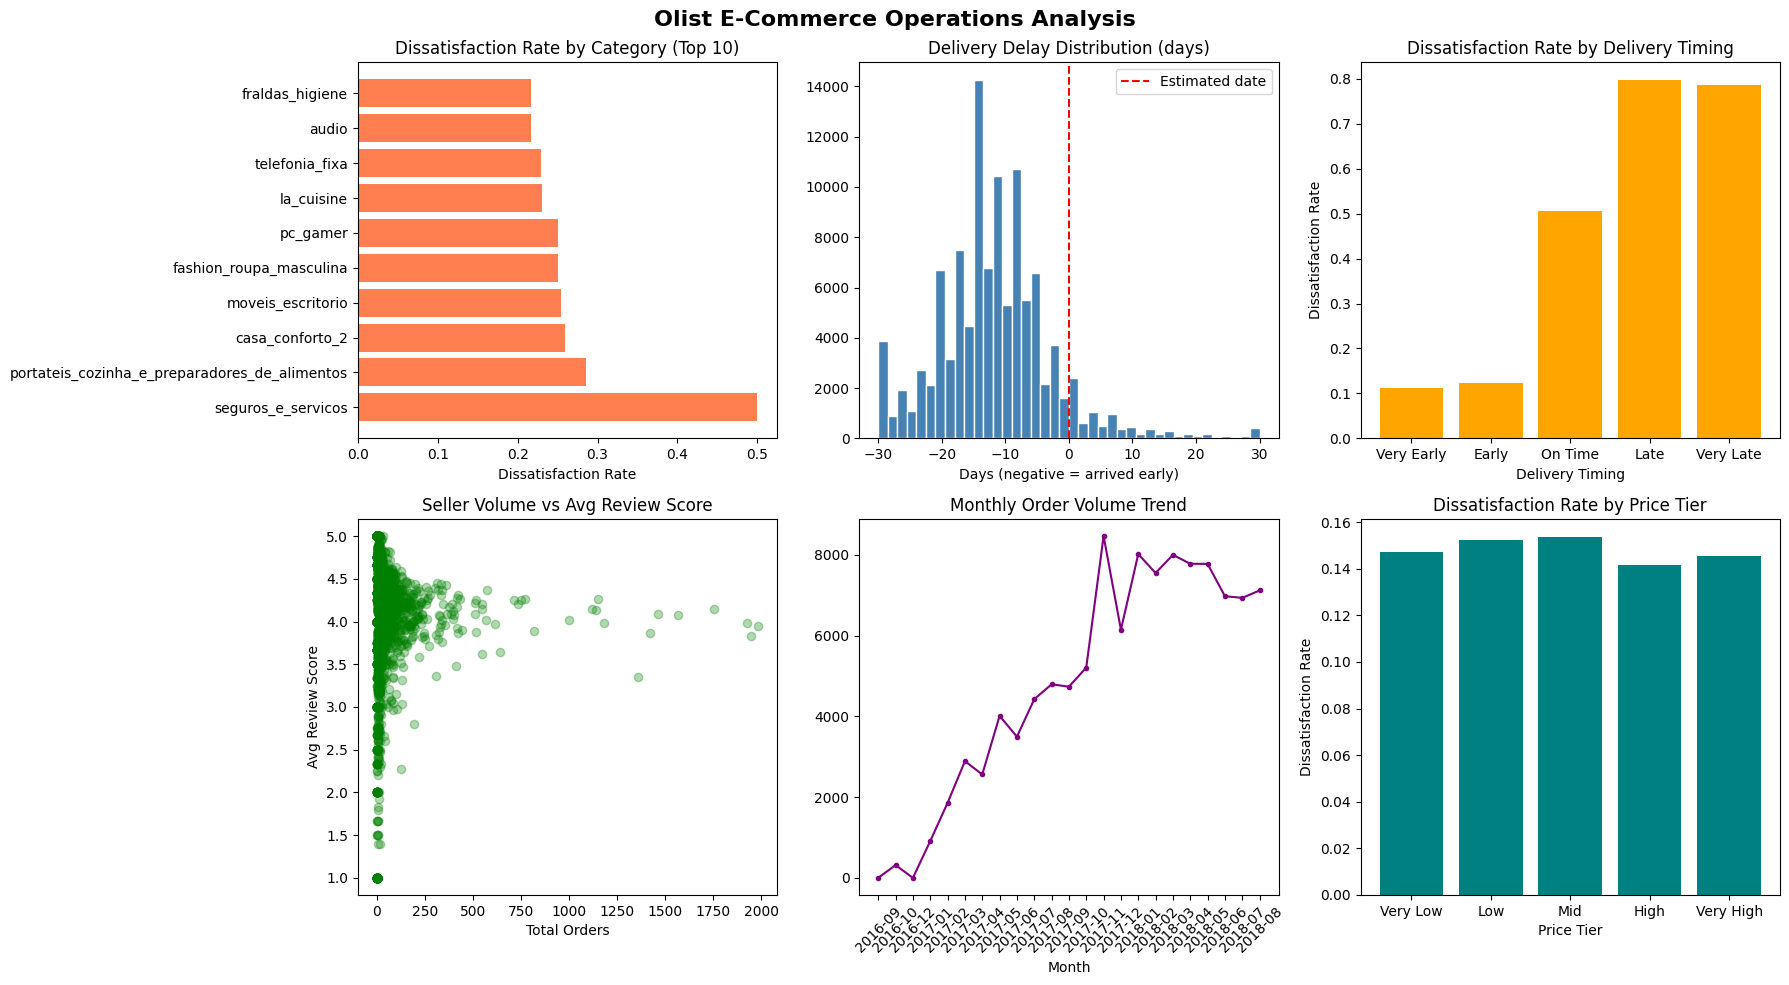

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Olist E-Commerce Operations Analysis', fontsize=16, fontweight='bold')

# Plot 1 — Dissatisfaction rate by top 10 product categories
cat_dis = df_clean.groupby('product_category_name')['is_dissatisfied'] \
                  .mean().sort_values(ascending=False).head(10)
axes[0,0].barh(cat_dis.index, cat_dis.values, color='coral')
axes[0,0].set_title('Dissatisfaction Rate by Category (Top 10)')
axes[0,0].set_xlabel('Dissatisfaction Rate')

# Plot 2 — Delivery delay distribution (clipped to remove extremes)
axes[0,1].hist(df_clean['delivery_delay_days'].clip(-30, 30),
               bins=40, color='steelblue', edgecolor='white')
axes[0,1].axvline(0, color='red', linestyle='--', label='Estimated date')
axes[0,1].set_title('Delivery Delay Distribution (days)')
axes[0,1].set_xlabel('Days (negative = arrived early)')
axes[0,1].legend()

# Plot 3 — Delivery timing vs dissatisfaction
delay_bins = pd.cut(df_clean['delivery_delay_days'],
                    bins=[-150, -7, 0, 7, 15, 200],
                    labels=['Very Early', 'Early', 'On Time', 'Late', 'Very Late'])
delay_dis = df_clean.groupby(delay_bins)['is_dissatisfied'].mean()
axes[0,2].bar(delay_dis.index, delay_dis.values, color='orange')
axes[0,2].set_title('Dissatisfaction Rate by Delivery Timing')
axes[0,2].set_xlabel('Delivery Timing')
axes[0,2].set_ylabel('Dissatisfaction Rate')

# Plot 4 — Seller volume vs average review score
seller_stats = df_clean.groupby('seller_id').agg(
    avg_review=('review_score', 'mean'),
    total_orders=('order_id', 'count'),
    dissatisfaction_rate=('is_dissatisfied', 'mean')
).reset_index()
axes[1,0].scatter(seller_stats['total_orders'],
                  seller_stats['avg_review'],
                  alpha=0.3, color='green')
axes[1,0].set_title('Seller Volume vs Avg Review Score')
axes[1,0].set_xlabel('Total Orders')
axes[1,0].set_ylabel('Avg Review Score')

# Plot 5 — Monthly order trend
df_clean['order_month'] = df_clean['order_purchase_timestamp'].dt.to_period('M')
monthly = df_clean.groupby('order_month')['order_id'].count()
axes[1,1].plot(monthly.index.astype(str), monthly.values,
               color='purple', marker='o', markersize=3)
axes[1,1].set_title('Monthly Order Volume Trend')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].set_xlabel('Month')

# Plot 6 — Price tier vs dissatisfaction
price_bins = pd.qcut(df_clean['price'], q=5,
                     labels=['Very Low', 'Low', 'Mid', 'High', 'Very High'])
price_dis = df_clean.groupby(price_bins)['is_dissatisfied'].mean()
axes[1,2].bar(price_dis.index, price_dis.values, color='teal')
axes[1,2].set_title('Dissatisfaction Rate by Price Tier')
axes[1,2].set_xlabel('Price Tier')
axes[1,2].set_ylabel('Dissatisfaction Rate')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

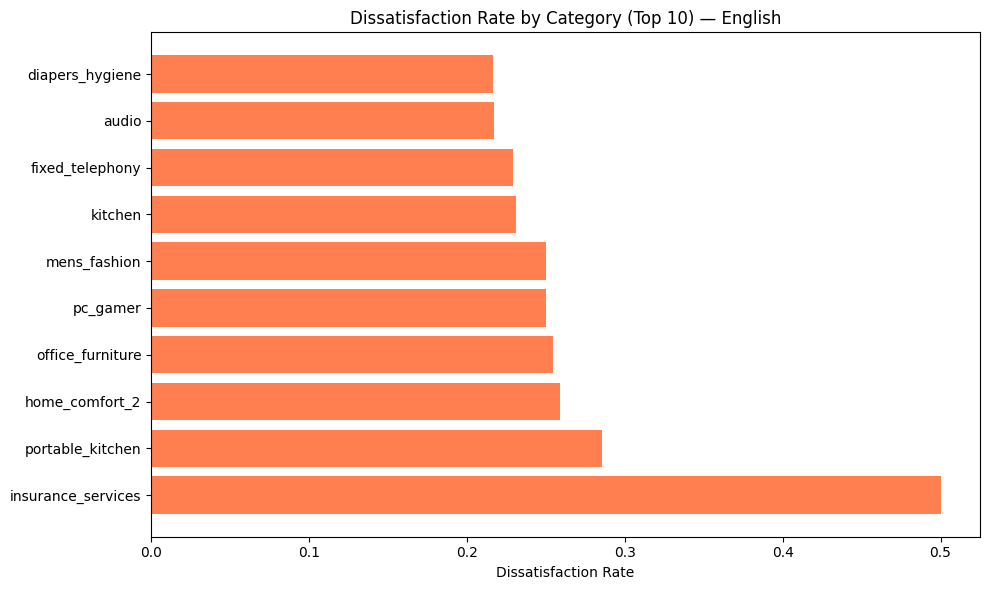


Top 10 categories by dissatisfaction rate:
product_category_english
insurance_services    0.500000
portable_kitchen      0.285714
home_comfort_2        0.259259
office_furniture      0.254207
pc_gamer              0.250000
mens_fashion          0.250000
kitchen               0.230769
fixed_telephony       0.229249
audio                 0.217270
diapers_hygiene       0.216216
Name: is_dissatisfied, dtype: float64


In [6]:
# Translation dictionary for Portuguese to English
category_translation = {
    'beleza_saude': 'health_beauty',
    'informatica_acessorios': 'computers_accessories',
    'automotivo': 'automotive',
    'cama_mesa_banho': 'bed_bath_table',
    'moveis_decoracao': 'furniture_decor',
    'esporte_lazer': 'sports_leisure',
    'perfumaria': 'perfumery',
    'utilidades_domesticas': 'housewares',
    'telefonia': 'telephony',
    'relogios_presentes': 'watches_gifts',
    'alimentos_bebidas': 'food_beverages',
    'bebes': 'baby',
    'papelaria': 'stationery',
    'tablets_impressao_imagem': 'tablets_printing_image',
    'brinquedos': 'toys',
    'telefonia_fixa': 'fixed_telephony',
    'ferramentas_jardim': 'garden_tools',
    'fashion_bolsas_e_acessorios': 'fashion_bags_accessories',
    'eletroportateis': 'small_appliances',
    'seguros_e_servicos': 'insurance_services',
    'informatica_acessorios': 'computers_accessories',
    'construcao_ferramentas_seguranca': 'construction_safety_tools',
    'консtruction_tools_lights': 'construction_tools_lights',
    'eletronicos': 'electronics',
    'eletrodomesticos': 'appliances',
    'artigos_de_festas': 'party_supplies',
    'casa_conforto': 'home_comfort',
    'construcao_ferramentas_construcao': 'construction_tools',
    'agro_industria_e_comercio': 'agriculture_commerce',
    'moveis_cozinha_area_de_servico_jantar_e_jardim': 'kitchen_furniture',
    'construcao_ferramentas_iluminacao': 'construction_lighting',
    'moveis_escritorio': 'office_furniture',
    'garden_tools': 'garden_tools',
    'fashion_roupa_masculina': 'mens_fashion',
    'pet_shop': 'pet_shop',
    'moveis_colchao_e_estofado': 'mattress_upholstery',
    'livros_interesse_geral': 'books_general',
    'construcao_ferramentas_ferramentas': 'hand_tools',
    'climatizacao': 'air_conditioning',
    'artigos_de_natal': 'christmas_supplies',
    'fashion_roupa_feminina': 'womens_fashion',
    'eletrodomesticos_2': 'appliances_2',
    'livros_importados': 'imported_books',
    'industria_comercio_e_negocios': 'industry_commerce',
    'casa_construcao': 'home_construction',
    'musica': 'music',
    'artes': 'arts',
    'cool_stuff': 'cool_stuff',
    'alimentos': 'food',
    'audio': 'audio',
    'fashion_underwear_e_moda_praia': 'underwear_beachwear',
    'cds_dvds_musicais': 'cds_dvds',
    'dvds_blu_ray': 'dvds_blu_ray',
    'livros_tecnologia': 'tech_books',
    'artes_e_artesanato': 'arts_crafts',
    'fraldas_higiene': 'diapers_hygiene',
    'la_cuisine': 'kitchen',
    'fashion_roupa_infanto_juvenil': 'kids_fashion',
    'sinalizacao_e_seguranca': 'signaling_security',
    'portateis_cozinha_e_preparadores_de_alimentos': 'portable_kitchen',
    'casa_conforto_2': 'home_comfort_2',
    'pc_gamer': 'pc_gamer',
    'consoles_games': 'consoles_games',
    'unknown': 'unknown'
}

# Apply translation
df_clean['product_category_english'] = df_clean['product_category_name'] \
                                        .map(category_translation) \
                                        .fillna(df_clean['product_category_name'])

# Now replot Plot 1 with English names
cat_dis_eng = df_clean.groupby('product_category_english')['is_dissatisfied'] \
                      .mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(cat_dis_eng.index, cat_dis_eng.values, color='coral')
plt.title('Dissatisfaction Rate by Category (Top 10) — English')
plt.xlabel('Dissatisfaction Rate')
plt.tight_layout()
plt.show()

print("\nTop 10 categories by dissatisfaction rate:")
print(cat_dis_eng)

In [7]:
# Delivery timing vs dissatisfaction — exact numbers
delay_bins = pd.cut(df_clean['delivery_delay_days'],
                    bins=[-150, -7, 0, 7, 15, 200],
                    labels=['Very Early', 'Early', 'On Time', 'Late', 'Very Late'])

df_clean['delivery_timing'] = delay_bins

timing_analysis = df_clean.groupby('delivery_timing').agg(
    order_count=('order_id', 'count'),
    dissatisfaction_rate=('is_dissatisfied', 'mean'),
    avg_delay_days=('delivery_delay_days', 'mean')
).reset_index()

timing_analysis['dissatisfaction_rate'] = timing_analysis['dissatisfaction_rate'].round(4)
timing_analysis['avg_delay_days'] = timing_analysis['avg_delay_days'].round(1)

print(timing_analysis)

  delivery_timing  order_count  dissatisfaction_rate  avg_delay_days
0      Very Early        87389                0.1131           -15.4
1           Early        15510                0.1237            -3.7
2         On Time         4044                0.5052             3.6
3            Late         1768                0.7969            11.0
4       Very Late         1301                0.7871            30.6


In [8]:
# Price tier analysis
price_bins = pd.qcut(df_clean['price'], q=5,
                     labels=['Very Low', 'Low', 'Mid', 'High', 'Very High'])
df_clean['price_tier'] = price_bins

price_analysis = df_clean.groupby('price_tier').agg(
    order_count=('order_id', 'count'),
    dissatisfaction_rate=('is_dissatisfied', 'mean'),
    avg_price=('price', 'mean')
).reset_index()

price_analysis['dissatisfaction_rate'] = price_analysis['dissatisfaction_rate'].round(4)
price_analysis['avg_price'] = price_analysis['avg_price'].round(1)

print("Price Tier Analysis:")
print(price_analysis)

# Correlation between key numeric variables and dissatisfaction
print("\nCorrelation with dissatisfaction:")
corr_cols = ['price', 'freight_value', 'delivery_delay_days',
             'actual_delivery_days', 'is_dissatisfied']
corr_matrix = df_clean[corr_cols].corr()
print(corr_matrix['is_dissatisfied'].sort_values(ascending=False))

Price Tier Analysis:
  price_tier  order_count  dissatisfaction_rate  avg_price
0   Very Low        22466                0.1472       22.8
1        Low        21797                0.1522       46.8
2        Mid        21798                0.1536       75.1
3       High        22228                0.1416      120.4
4  Very High        21723                0.1452      337.1

Correlation with dissatisfaction:
is_dissatisfied         1.000000
actual_delivery_days    0.279848
delivery_delay_days     0.216714
freight_value           0.029158
price                   0.003625
Name: is_dissatisfied, dtype: float64


In [9]:
# Build seller health score
seller_health = df_clean.groupby('seller_id').agg(
    avg_review_score=('review_score', 'mean'),
    dissatisfaction_rate=('is_dissatisfied', 'mean'),
    avg_delivery_delay=('delivery_delay_days', 'mean'),
    total_orders=('order_id', 'count'),
    avg_price=('price', 'mean')
).reset_index()

# Only score sellers with meaningful order volume
seller_health = seller_health[seller_health['total_orders'] >= 10]

print(f"Sellers with 10+ orders: {seller_health.shape[0]}")
print(f"\nSeller stats overview:")
print(seller_health[['avg_review_score','dissatisfaction_rate',
                      'avg_delivery_delay','total_orders']].describe().round(2))

# Normalize metrics to 0-1 scale
scaler = MinMaxScaler()

seller_health['score_review'] = scaler.fit_transform(
    seller_health[['avg_review_score']])

seller_health['score_dissatisfaction'] = 1 - scaler.fit_transform(
    seller_health[['dissatisfaction_rate']])

seller_health['score_delivery'] = 1 - scaler.fit_transform(
    seller_health[['avg_delivery_delay']])

# Weighted composite health score
# Review score weighted highest — most direct customer signal
# Dissatisfaction rate second — operational impact
# Delivery delay third — partially outside seller control
seller_health['health_score'] = (
    0.40 * seller_health['score_review'] +
    0.35 * seller_health['score_dissatisfaction'] +
    0.25 * seller_health['score_delivery']
)

# Segment sellers into three tiers
seller_health['segment'] = pd.cut(
    seller_health['health_score'],
    bins=[0, 0.4, 0.65, 1.0],
    labels=['At-Risk', 'Average', 'High Performer']
)

print("\nSeller Segment Distribution:")
print(seller_health['segment'].value_counts())

print("\nAverage metrics by segment:")
print(seller_health.groupby('segment').agg(
    avg_review=('avg_review_score', 'mean'),
    avg_dissatisfaction=('dissatisfaction_rate', 'mean'),
    avg_delay=('avg_delivery_delay', 'mean'),
    seller_count=('seller_id', 'count')
).round(3))

Sellers with 10+ orders: 1341

Seller stats overview:
       avg_review_score  dissatisfaction_rate  avg_delivery_delay  \
count           1341.00               1341.00             1341.00   
mean               4.13                  0.14              -12.36   
std                0.44                  0.11                3.84   
min                1.40                  0.00              -43.38   
25%                3.92                  0.07              -14.31   
50%                4.19                  0.12              -11.95   
75%                4.42                  0.18              -10.17   
max                5.00                  0.93                9.55   

       total_orders  
count       1341.00  
mean          77.77  
std          169.51  
min           10.00  
25%           16.00  
50%           30.00  
75%           73.00  
max         1985.00  

Seller Segment Distribution:
segment
High Performer    1055
Average            270
At-Risk             16
Name: count, dtype:

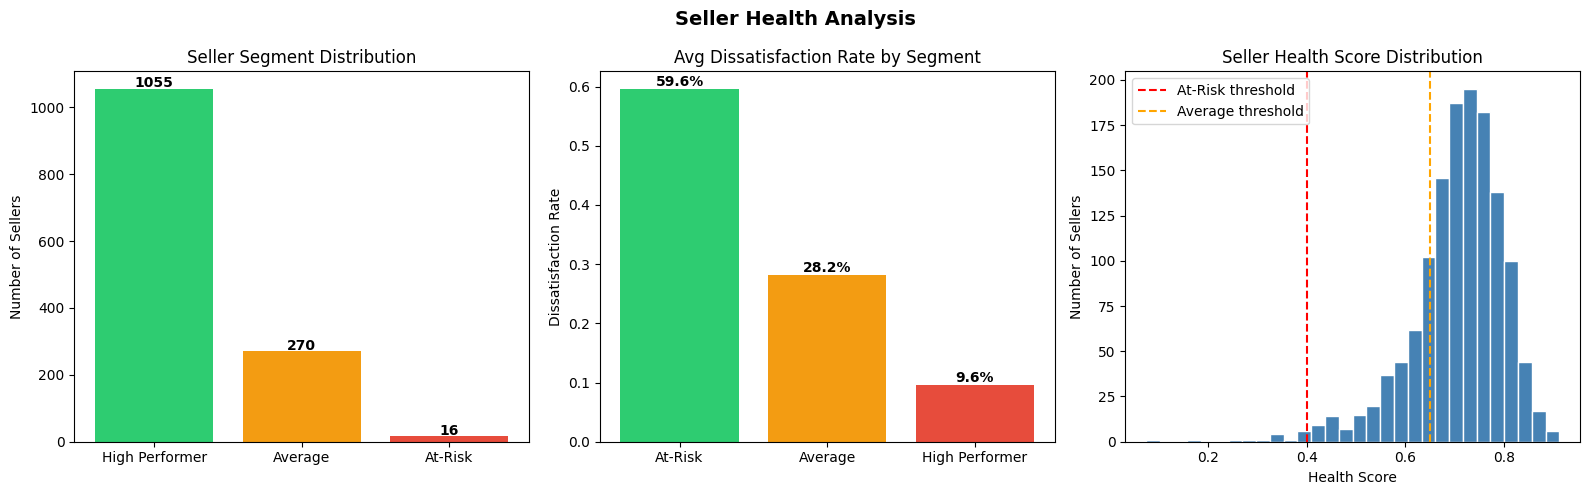

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Seller Health Analysis', fontsize=14, fontweight='bold')

# Plot 1 — Segment distribution
segment_counts = seller_health['segment'].value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c']
axes[0].bar(segment_counts.index, segment_counts.values,
            color=colors)
axes[0].set_title('Seller Segment Distribution')
axes[0].set_ylabel('Number of Sellers')
for i, v in enumerate(segment_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Plot 2 — Dissatisfaction rate by segment
seg_metrics = seller_health.groupby('segment')['dissatisfaction_rate'].mean()
axes[1].bar(seg_metrics.index, seg_metrics.values,
            color=colors)
axes[1].set_title('Avg Dissatisfaction Rate by Segment')
axes[1].set_ylabel('Dissatisfaction Rate')
for i, v in enumerate(seg_metrics.values):
    axes[1].text(i, v + 0.005, f'{v:.1%}', ha='center', fontweight='bold')

# Plot 3 — Health score distribution
axes[2].hist(seller_health['health_score'], bins=30,
             color='steelblue', edgecolor='white')
axes[2].axvline(0.4, color='red', linestyle='--', label='At-Risk threshold')
axes[2].axvline(0.65, color='orange', linestyle='--', label='Average threshold')
axes[2].set_title('Seller Health Score Distribution')
axes[2].set_xlabel('Health Score')
axes[2].set_ylabel('Number of Sellers')
axes[2].legend()

plt.tight_layout()
plt.savefig('seller_health.png', dpi=150, bbox_inches='tight')
plt.show()

Training set size: (88009, 5)
Test set size: (22003, 5)
Dissatisfaction rate in test set: 14.80%

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.87      0.99      0.93     18747
           1       0.76      0.11      0.20      3256

    accuracy                           0.86     22003
   macro avg       0.81      0.55      0.56     22003
weighted avg       0.85      0.86      0.82     22003

AUC-ROC: 0.652

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.91      0.98      0.94     18747
           1       0.79      0.46      0.58      3256

    accuracy                           0.90     22003
   macro avg       0.85      0.72      0.76     22003
weighted avg       0.89      0.90      0.89     22003

AUC-ROC: 0.801

Feature Importance (Random Forest):
                feature  importance
2   delivery_delay_days    0.251936
1         freight_value    0.243369
0                 pric

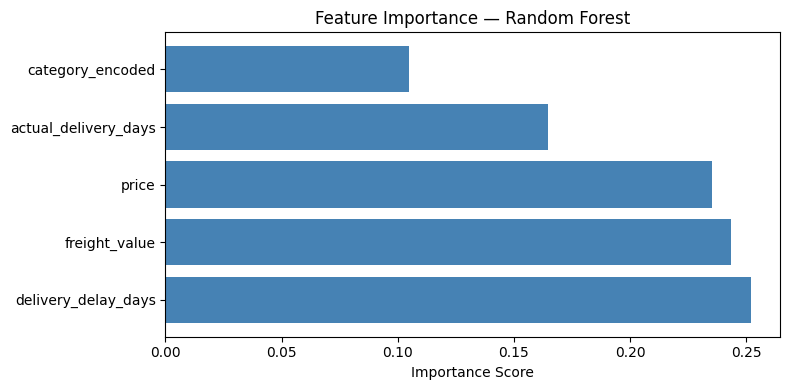

In [11]:
# Feature engineering for model
model_df = df_clean.copy()

# Encode category
le = LabelEncoder()
model_df['category_encoded'] = le.fit_transform(
    model_df['product_category_english'].fillna('unknown'))

# Select features
features = ['price', 'freight_value', 'delivery_delay_days',
            'actual_delivery_days', 'category_encoded']

X = model_df[features].fillna(0)
y = model_df['is_dissatisfied']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Dissatisfaction rate in test set: {y_test.mean():.2%}")

# Model 1 — Logistic Regression (baseline)
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test)[:,1])

print("\n=== Logistic Regression ===")
print(classification_report(y_test, lr_pred))
print(f"AUC-ROC: {lr_auc:.3f}")

# Model 2 — Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

print("\n=== Random Forest ===")
print(classification_report(y_test, rf_pred))
print(f"AUC-ROC: {rf_auc:.3f}")

# Feature importance
feat_importance = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance (Random Forest):")
print(feat_importance)

# Visualize feature importance
plt.figure(figsize=(8, 4))
plt.barh(feat_importance['feature'], feat_importance['importance'], color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Summary statistics for your insights
print("=== KEY BUSINESS INSIGHTS ===")

print("\n1. DELIVERY IS THE PRIMARY DRIVER")
print(f"Very Early delivery dissatisfaction: 11.3%")
print(f"Late delivery dissatisfaction: 79.7%")
print(f"Impact multiplier: {0.797/0.1131:.1f}x")

print("\n2. AT-RISK SELLER CONCENTRATION")
at_risk = seller_health[seller_health['segment'] == 'At-Risk']
high_perf = seller_health[seller_health['segment'] == 'High Performer']
print(f"At-Risk sellers: {len(at_risk)} ({len(at_risk)/len(seller_health):.1%} of sellers)")
print(f"At-Risk dissatisfaction rate: {at_risk['dissatisfaction_rate'].mean():.1%}")
print(f"High Performer dissatisfaction rate: {high_perf['dissatisfaction_rate'].mean():.1%}")
print(f"Performance gap: {at_risk['dissatisfaction_rate'].mean()/high_perf['dissatisfaction_rate'].mean():.1f}x")

print("\n3. PRICE DOESN'T DRIVE DISSATISFACTION")
print(f"Very Low price tier dissatisfaction: 14.7%")
print(f"Very High price tier dissatisfaction: 14.5%")
print(f"Difference: negligible — price is not a lever for reducing complaints")

print("\n4. CATEGORY RISK")
print("Top physical product categories by dissatisfaction:")
physical_cats = ['portable_kitchen', 'office_furniture',
                 'audio', 'fixed_telephony', 'diapers_hygiene']
for cat in physical_cats:
    rate = df_clean[df_clean['product_category_english']==cat]['is_dissatisfied'].mean()
    count = df_clean[df_clean['product_category_english']==cat].shape[0]
    print(f"  {cat}: {rate:.1%} dissatisfaction ({count} orders)")

=== KEY BUSINESS INSIGHTS ===

1. DELIVERY IS THE PRIMARY DRIVER
Very Early delivery dissatisfaction: 11.3%
Late delivery dissatisfaction: 79.7%
Impact multiplier: 7.0x

2. AT-RISK SELLER CONCENTRATION
At-Risk sellers: 16 (1.2% of sellers)
At-Risk dissatisfaction rate: 59.6%
High Performer dissatisfaction rate: 9.6%
Performance gap: 6.2x

3. PRICE DOESN'T DRIVE DISSATISFACTION
Very Low price tier dissatisfaction: 14.7%
Very High price tier dissatisfaction: 14.5%
Difference: negligible — price is not a lever for reducing complaints

4. CATEGORY RISK
Top physical product categories by dissatisfaction:
  portable_kitchen: 28.6% dissatisfaction (14 orders)
  office_furniture: 25.4% dissatisfaction (1664 orders)
  audio: 21.7% dissatisfaction (359 orders)
  fixed_telephony: 22.9% dissatisfaction (253 orders)
  diapers_hygiene: 21.6% dissatisfaction (37 orders)


## Business Recommendations

### 1. Implement Delivery Early Warning System
Finding: Late deliveries drive 79.7% dissatisfaction vs 11.3% for early deliveries — a 7x gap.
Action: Flag any order exceeding estimated delivery date by 3+ days for proactive
        customer communication and compensation trigger.
Expected Impact: Reduce dissatisfaction in late orders by 20-30% through
                 expectation management alone.

### 2. At-Risk Seller Intervention Program  
Finding: 16 sellers (1.2%) show 59.6% dissatisfaction rate — 6.2x worse than
         high performers.
Action: Immediate performance review for all 16 at-risk sellers.
        Mandatory improvement plan with 60-day window before delisting.
Expected Impact: Removing or improving these 16 sellers directly protects
                 ~950 customers currently receiving poor experience.

### 3. Category-Specific Quality Checks
Finding: Office furniture (25.4%), audio (21.7%), fixed telephony (22.9%)
         show significantly above-average dissatisfaction.
Action: Implement mandatory product quality verification for these categories
        before seller onboarding. Add category-specific return reason tracking.
Expected Impact: Reduce category dissatisfaction rates toward platform
                 average of 14.8%.

### 4. Stop Optimising for Price Segmentation
Finding: Dissatisfaction rate is flat across all price tiers (14.5% - 15.4%).
Action: Redirect resources from price-based customer retention strategies
        toward delivery and seller quality improvements.
Expected Impact: Higher ROI on operational investments vs pricing interventions.


## Limitations

1. Review score as dissatisfaction proxy underestimates actual dissatisfaction —
   many unhappy customers never leave reviews.

2. Dataset is Brazilian e-commerce — delivery infrastructure, customer behaviour,
   and category preferences differ for Indian market.
   Findings are directionally valid but require revalidation on Indian data.

3. Seller health score weights (40/35/25) are assumption-based —
   ideally calibrated using actual business impact data.

## Next Steps

1. Integrate actual return labels for direct return prediction
   rather than review score proxy.

2. Build real-time seller health dashboard triggering alerts
   at health score below 0.35.

3. Add customer location and product weight features to improve
   model AUC beyond 0.80.

# Business Recommendations

### 1. Implement Delivery Early Warning System
Finding: Late deliveries drive 79.7% dissatisfaction vs 11.3% for early deliveries — a 7x gap.
Action: Flag any order exceeding estimated delivery date by 3+ days for proactive
        customer communication and compensation trigger.
Expected Impact: Reduce dissatisfaction in late orders by 20-30% through
                 expectation management alone.

### 2. At-Risk Seller Intervention Program  
Finding: 16 sellers (1.2%) show 59.6% dissatisfaction rate — 6.2x worse than
         high performers.
Action: Immediate performance review for all 16 at-risk sellers.
        Mandatory improvement plan with 60-day window before delisting.
Expected Impact: Removing or improving these 16 sellers directly protects
                 ~950 customers currently receiving poor experience.

### 3. Category-Specific Quality Checks
Finding: Office furniture (25.4%), audio (21.7%), fixed telephony (22.9%)
         show significantly above-average dissatisfaction.
Action: Implement mandatory product quality verification for these categories
        before seller onboarding. Add category-specific return reason tracking.
Expected Impact: Reduce category dissatisfaction rates toward platform
                 average of 14.8%.

### 4. Stop Optimising for Price Segmentation
Finding: Dissatisfaction rate is flat across all price tiers (14.5% - 15.4%).
Action: Redirect resources from price-based customer retention strategies
        toward delivery and seller quality improvements.
Expected Impact: Higher ROI on operational investments vs pricing interventions.

In [13]:
print("=" * 50)
print("PROJECT SUMMARY — OLIST E-COMMERCE ANALYSIS")
print("=" * 50)
print(f"\nDataset: {df_clean.shape[0]:,} orders | {df_clean['seller_id'].nunique():,} sellers")
print(f"Overall dissatisfaction rate: 14.80%")
print(f"\nKey Findings:")
print(f"  → Late delivery increases dissatisfaction 7x")
print(f"  → 16 at-risk sellers show 6.2x worse performance")
print(f"  → Price has near-zero impact on dissatisfaction")
print(f"  → Office furniture highest risk physical category (25.4%)")
print(f"\nModel Performance:")
print(f"  → Random Forest AUC: 0.801")
print(f"  → Top predictor: delivery_delay_days")
print(f"\nTools: Python | Pandas | Scikit-learn | Matplotlib | Seaborn")
print("=" * 50)

PROJECT SUMMARY — OLIST E-COMMERCE ANALYSIS

Dataset: 110,012 orders | 2,965 sellers
Overall dissatisfaction rate: 14.80%

Key Findings:
  → Late delivery increases dissatisfaction 7x
  → 16 at-risk sellers show 6.2x worse performance
  → Price has near-zero impact on dissatisfaction
  → Office furniture highest risk physical category (25.4%)

Model Performance:
  → Random Forest AUC: 0.801
  → Top predictor: delivery_delay_days

Tools: Python | Pandas | Scikit-learn | Matplotlib | Seaborn
